# Constructing EOS and solving TOV equations

This example notebook shows how to construct the equation of state with the metamodel and speed-of-sound extension scheme parametrization used in the paper, as well as solve the TOV equations. 

In [22]:
import numpy as np
np.random.seed(41) # for reproducibility
import matplotlib.pyplot as plt
import jesterTOV.utils as utils

## Equation of state

We will use the metamodel with speed-of-sound extension scheme to showcase how to create the EOS for this parametrization.

The `construct_eos` method takes a single argument containing all the necessary parameters in a dictionary. This consists of
- The NEPs: these parametrize the metamodel part of the EOS
- The CSE parameters: these are `nb_CSE` grid points with index `i` with density `n_CSE_u_i` and the speed of sound (squared) at that density `cs2_CSE_i`. NOTE: we the `u` in `n_CSE_u_i` stands for uniform between 0 and 1, which is the range in which the parameters are originally sampled. Internally, they are sorted and transformed to the desired density range. Since this range adapts dynamically as it depends on the value of the `nbreak` parameter, this small intermediate step can adapt to the `nbreak` value for each sample. 
- The parametrization ends at `nmax_nsat`, which is the maximal density in units of `nsat` up to which we interpolate the EOS. We therefore also add a value for the cs2 at this end point, but its density value is fixed and not varied internally. Note that the TOV solution might terminate at a central density that is lower than `nmax_nsat`.

In [23]:
from jesterTOV.eos.metamodel.metamodel_CSE import MetaModel_with_CSE_EOS_model
from jesterTOV.tov.data_classes import EOSData

In [24]:
nsat = 0.16 # nuclear saturation density in fm^-3

# Define the EOS object, here we focus on Metamodel with CSE
eos = MetaModel_with_CSE_EOS_model(nmax_nsat=6.0)

# Define the nuclear empirical parameters (NEPs) -- all in MeV
params_dict = {"E_sat": -16.0, # saturation parameters
               "K_sat": 200.0,
               "Q_sat": 0.0,
               "Z_sat": 0.0,
               "E_sym": 32.0, # symmetry parameters
               "L_sym": 45.0,
               "K_sym": -100.0,
               "Q_sym": 0.0,
               "Z_sym": 0.0,
            }

# Define the breakdown density -- this is usually between 1-2 nsat
nbreak = 1.5 * nsat
params_dict["nbreak"] = nbreak

# Need to add the CSE gridpoints parameters
# NOTE: the final density point is fixed to the maximum density, so we only need to add nb_CSE parameters for the n_CSE_i_u, and nb_CSE+1 parameters for the cs2_CSE_i
nb_CSE = 8
for i in range(nb_CSE):
    # Add n_CSE_i_u parameters (uniform [0, 1])
    n_CSE_dict = {f"n_CSE_{i}_u": np.random.uniform(0.0, 1.0) for i in range(nb_CSE)}
    cs2_CSE_dict = {f"cs2_CSE_{i}": np.random.uniform(0.0, 1.0) for i in range(nb_CSE+1)}
    
CSE_dict = {**n_CSE_dict, **cs2_CSE_dict}
params_dict.update(CSE_dict)

# Now create the EOS -- returns a NamedTuple, called EOSData
eos_data: EOSData = eos.construct_eos(params_dict)

# Extract quantities from the EOSData
ns, es, ps, cs2 = eos_data.ns, eos_data.es, eos_data.ps, eos_data.cs2

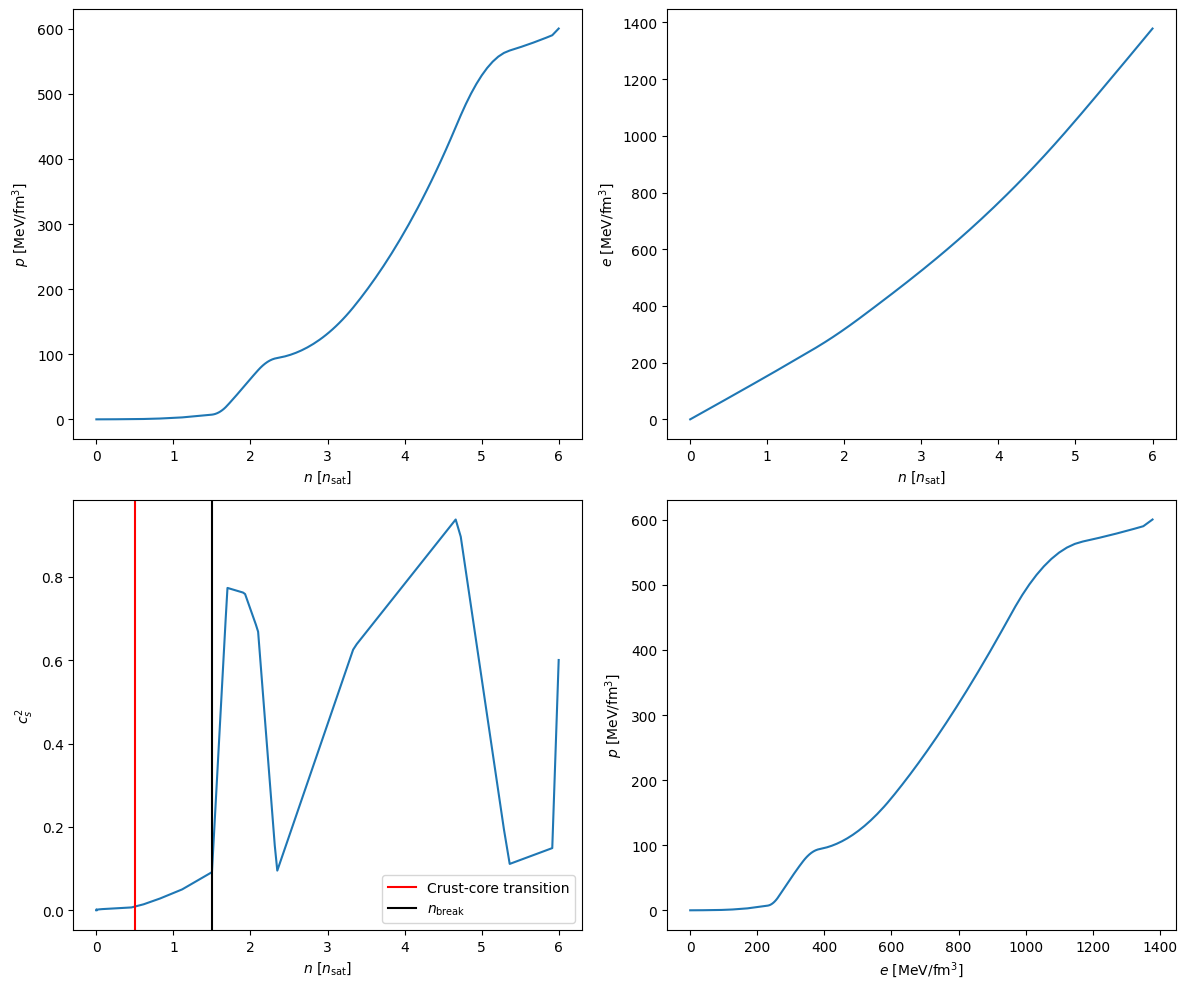

In [25]:
# Make a plot
plt.subplots(nrows = 2, ncols = 2, figsize = (12, 10))

# For the plot, let's make some conversions to more common units
ns_plots = ns / utils.fm_inv3_to_geometric / 0.16
es_plots = es / utils.MeV_fm_inv3_to_geometric
ps_plots = ps / utils.MeV_fm_inv3_to_geometric

# p(n)
plt.subplot(221)
plt.plot(ns_plots, ps_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")

# e(n)
plt.subplot(222)
plt.plot(ns_plots, es_plots)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$e$ [MeV/fm$^3$]")

# cs2(n)
plt.subplot(223)
plt.plot(ns_plots, cs2)
plt.xlabel(r"$n$ [$n_{\rm{sat}}$]")
plt.ylabel(r"$c_s^2$")
plt.axvline(0.5, color = "red", label = "Crust-core transition")
plt.axvline(nbreak / nsat, color = "black", label = r"$n_{\rm{break}}$")
plt.legend()

# p(e)
plt.subplot(224)
plt.plot(es_plots, ps_plots)
plt.xlabel(r"$e$ [MeV/fm$^3$]")
plt.ylabel(r"$p$ [MeV/fm$^3$]")
plt.tight_layout()
plt.show()
plt.close()

## TOV solver

Solving the TOV equations: the result is another dataclass, called FamilyData, which contains all the relevant quantities for the family of solutions (M-R curve, tidal deformabilities, etc.)

In [26]:
from jesterTOV.tov.data_classes import FamilyData
from jesterTOV.tov.gr import GRTOVSolver

In [27]:
gr_tov_solver = GRTOVSolver()
sol: FamilyData = gr_tov_solver.construct_family(eos_data=eos_data, ndat = 200, min_nsat = 1.0)

Make a plot of the solution:

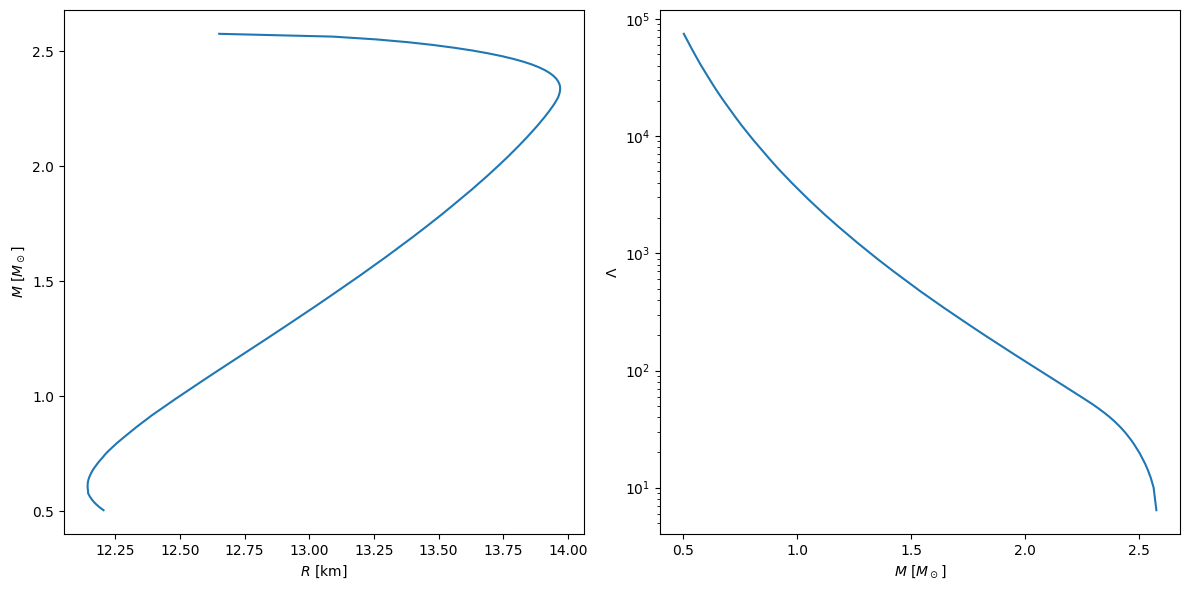

In [28]:
masses, radii, Lambdas = sol.masses, sol.radii, sol.lambdas

# Make a plot of the TOV solution
plt.subplots(nrows = 1, ncols = 2, figsize = (12, 6))

# Limit masses to be above certain mass to make plot prettier
m_min = 0.5
mask = masses > m_min
masses = masses[mask]
radii = radii[mask]
Lambdas = Lambdas[mask]

# M(R) plot
plt.subplot(121)
plt.plot(radii, masses)
plt.xlabel(r"$R$ [km]")
plt.ylabel(r"$M$ [$M_\odot$]")

# Lambda(R) plot
plt.subplot(122)
plt.plot(masses, Lambdas)
plt.xlabel(r"$M$ [$M_\odot$]")
plt.ylabel(r"$\Lambda$")
plt.yscale("log")
plt.tight_layout()
plt.show()
plt.close()